In [19]:
import sys
import os

sys.path.append("..")
sys.path.append("../..")
sys.path.append("../../..")

In [20]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import pandas as pd
from hydra import initialize, compose
from hydra.core.global_hydra import GlobalHydra

from experiment.utils.utils import logit

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [22]:
GlobalHydra.instance().clear()
initialize(version_base=None, config_path="../../config")

CONFIG = compose(config_name="config")

In [23]:
def price2bin(price):
    """
    price = 1.2 ** bin
    """
    if price <= 0:
        return 0
    return np.round(np.log(price) / np.log(1.2))

def bin2price(bin_):
    return np.power(1.2, bin_)

# Environment Sampling

In [24]:
NUM_AUCTIONS = 500

In [25]:
from datasets import load_dataset, load_from_disk

if not os.path.exists("../../data/BAT/vcg_campaigns") or not os.path.exists("../../data/BAT/vcg_stats"):
    vcg_campaigns = load_dataset("AvitoTech/BAT", "vcg_campaigns")
    vcg_stats = load_dataset("AvitoTech/BAT", "vcg_stats")

    vcg_campaigns.save_to_disk("../../data/BAT/vcg_campaigns")
    vcg_stats.save_to_disk("../../data/BAT/vcg_stats")

In [26]:
VCG_CAMPAIGNS = load_from_disk("../../data/BAT/vcg_campaigns")
VCG_STATS = load_from_disk("../../data/BAT/vcg_stats")

In [27]:
VCG_STATS_SUBSAMPLE_DF = pd.DataFrame(VCG_STATS["train"][:10_000_000])
VCG_STATS_SUBSAMPLE_DF = VCG_STATS_SUBSAMPLE_DF[VCG_STATS_SUBSAMPLE_DF["CTRPredicts"] >= 1e-9].reset_index()
VCG_CAMPAIGNS_DF = pd.DataFrame(VCG_CAMPAIGNS["train"])

unique_campaign_ids = VCG_STATS_SUBSAMPLE_DF["campaign_id"].unique()

VCG_CAMPAIGNS_SUBSAMPLE_DF = VCG_CAMPAIGNS_DF[
    VCG_CAMPAIGNS_DF["campaign_id"].isin(unique_campaign_ids)
].reset_index()

In [28]:
mask = VCG_STATS_SUBSAMPLE_DF.groupby("campaign_id")["AuctionCount"].transform("count") >= NUM_AUCTIONS
VCG_STATS_SUBSAMPLE_DF_FILTERED = VCG_STATS_SUBSAMPLE_DF[mask].copy().reset_index(drop=True)
CAMPAIGN_IDS = VCG_STATS_SUBSAMPLE_DF_FILTERED["campaign_id"].unique()

In [29]:
# CAMPAIGN_IDS.shape

In [30]:
def sample_campaign(
    seed,
    campaign_id,
    sigma_ctr = 0.0,
    sigma_cvr = 0.0,
    vcg_stats_df = VCG_STATS_SUBSAMPLE_DF_FILTERED,
):
    rng = np.random.default_rng(seed)
    campaign = vcg_stats_df[vcg_stats_df["campaign_id"] == campaign_id]

    weights = np.array(campaign["AuctionCount"], dtype=np.float64)
    weights /= weights.sum()

    idxs = rng.choice(len(campaign), size=len(campaign), p=weights, replace=True)
    logs = vcg_stats_df.iloc[idxs]

    place_count = logs["AuctionCount"]
    ctr_clean = np.array(logs["CTRPredicts"] / place_count)
    cvr_clean = np.array(logs["CRPredicts"] / place_count)
    wp = np.array(bin2price(logs["contact_price_bin"]) / place_count)

    ctr_clean_logit = logit(ctr_clean)
    cvr_clean_logit = logit(cvr_clean)
    ctr_noised_logit = ctr_clean_logit + rng.normal(0, sigma_ctr, len(campaign))
    cvr_noised_logit = cvr_clean_logit + rng.normal(0, sigma_cvr, len(campaign))

    return ctr_clean_logit, ctr_noised_logit, cvr_clean_logit, cvr_noised_logit, wp

In [31]:
from experiment.denoise_bid.ctr_only.expectation import ctr_expectation
from experiment.denoise_bid.ctr_only.gmm import fit_gmm
from experiment.denoise_bid.ctr_only.bid import bids as denoise_bid

from experiment.non_robust_bid.lp import solve_dual as non_robust_dual

from experiment.utils.utils import sigmoid

In [32]:
import numpy as np
from scipy.stats import norm


def get_posterior_samples(ctr_logit, ctr_sigma, weights, means, sigmas, n_samples=5000):
    T = len(ctr_logit)
    K = len(weights)

    post_mu = np.zeros((T, K))
    post_var = np.zeros((T, K))
    post_weights = np.zeros((T, K))
    
    for k in range(K):
        post_var[:, k] = 1 / (1 / ctr_sigma**2 + 1 / sigmas[k]**2)
        post_mu[:, k] = post_var[:, k] * (ctr_logit / ctr_sigma**2 + means[k] / sigmas[k]**2)

        multiplier = norm.pdf(ctr_logit, means[k], np.sqrt(ctr_sigma**2 + sigmas[k]**2))
        post_weights[:, k] = weights[k] * multiplier

    post_weights /= (post_weights.sum(axis=1, keepdims=True) + 1e-10)
    post_weights /= (post_weights.sum(axis=1, keepdims=True))

    samples = np.zeros((n_samples, T))
    for t in range(T):
        components = np.random.choice(K, size=n_samples, p=post_weights[t])
        sampled_logits = np.random.normal(post_mu[t, components], np.sqrt(post_var[t, components]))
        samples[:, t] = sigmoid(sampled_logits)
        
    return samples

def run_cpc_gap_experiment(campaign_id, sigma, budget_factor=0.2, target_cpc_factor=0.2):
    cl_logit, n_logit, _, _, wp = sample_campaign(seed=42, campaign_id=campaign_id, sigma_ctr=sigma)

    n_components = 2
    n_mc = 10_000

    campaign_mean_cpc = np.sum(wp) / np.sum(sigmoid(cl_logit))
    target_cpc = target_cpc_factor * campaign_mean_cpc
    budget = budget_factor * np.sum(wp)

    idx = np.random.choice(len(n_logit), size=min(len(n_logit), 100 * n_components), replace=False)
    weights, means, sigmas = fit_gmm(CONFIG.algorithms.denoise_bid.ctr_only, n_logit[idx], np.full_like(n_logit[idx], sigma), n_components)

    e_ctr = ctr_expectation(n_logit, np.full_like(n_logit, sigma), weights, means, sigmas)
    cvr = sigmoid(cl_logit)

    p, q = non_robust_dual(CONFIG.algorithms.non_robust_bid, e_ctr, cvr, wp, budget, target_cpc)

    current_bids = denoise_bid(e_ctr, cvr, p, q, target_cpc)
    x_t = (current_bids >= wp).astype(float)

    total_cost = np.sum(x_t * wp)
    surrogate_clicks = np.sum(x_t * e_ctr)
    surrogate_cpc = total_cost / (surrogate_clicks + 1e-10)


    ctr_samples = get_posterior_samples(n_logit, np.full_like(n_logit, sigma), weights, means, sigmas, n_samples=n_mc)
    
    mc_ratios = []
    for s in range(n_mc):
        clicks_s = np.sum(x_t * ctr_samples[s, :])
        mc_ratios.append(total_cost / (clicks_s + 1e-10))
        
    true_expected_cpc = np.mean(mc_ratios)

    abs_error = np.abs(surrogate_cpc - true_expected_cpc)
    rel_error = abs_error / true_expected_cpc
    
    return {
        "sigma": sigma,
        "surrogate_cpc": surrogate_cpc,
        "true_cpc": true_expected_cpc,
        "rel_error_pct": rel_error * 100
    }

In [33]:
SIGMAS = np.logspace(-2, 1, 10)
SELECTED_CAMPAIGNS = CAMPAIGN_IDS[:100]

all_errors = []

print(f"CPC Gap Experiment on {len(SELECTED_CAMPAIGNS)} campaigns...")

for s in tqdm(SIGMAS, desc="Sigmas"):
    sigma_errors = []
    for camp_id in SELECTED_CAMPAIGNS:
        res = run_cpc_gap_experiment(campaign_id=camp_id, sigma=s)
        sigma_errors.append(res['rel_error_pct'])

    all_errors.append(sigma_errors)

mean_errors = [np.mean(e) for e in all_errors]
std_errors = [np.std(e) for e in all_errors]

CPC Gap Experiment on 100 campaigns...


Sigmas: 100%|██████████| 10/10 [20:47<00:00, 124.78s/it]


In [34]:
print("\nResults Table:")
print("Sigma | Mean Error (%) | Std Dev")
print("-" * 35)
for s, m, std in zip(SIGMAS, mean_errors, std_errors):
    print(f"{s:.3f} | {m:.4f}% | {std:.4f}")


Results Table:
Sigma | Mean Error (%) | Std Dev
-----------------------------------
0.010 | 0.0007% | 0.0004
0.022 | 0.0031% | 0.0012
0.046 | 0.0148% | 0.0038
0.100 | 0.0675% | 0.0140
0.215 | 0.2975% | 0.0573
0.464 | 1.0349% | 0.2055
1.000 | 2.0196% | 0.7627
2.154 | 3.7461% | 1.2398
4.642 | 6.2064% | 2.6455
10.000 | 5.9379% | 4.9978


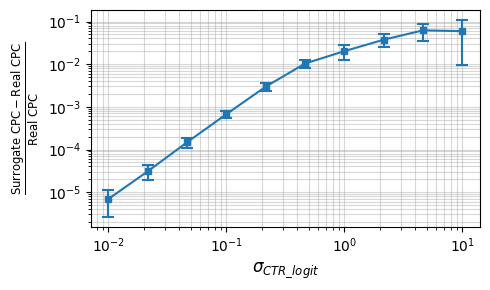

In [40]:
plt.figure(figsize=(5, 3))

plt.errorbar(
    SIGMAS,
    np.array(mean_errors)/100,
    yerr=np.array(std_errors) / 100,
    fmt="s-",
    capsize=4,
    capthick=1.5,
    elinewidth=1.5,
    markersize=4,
    label='Relative Error'
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\sigma_{CTR\_logit}$', fontsize=12)
plt.ylabel(r'$\frac{\text{Surrogate CPC} - \text{Real CPC}}{\text{Real CPC}}$', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.axhline(0, color='black', lw=1)

max_err = max(mean_errors)

plt.tight_layout()
plt.savefig('cpc_approximation_gap.pdf')
plt.show()